# Estudo 6 — Análise Estatística

Este estudo investiga as distribuições, a concentração, as relações, as observações atípicas e os padrões multivariados presentes nos indicadores estaduais da população indígena brasileira.

> **Pergunta central:** Como se distribuem e se relacionam os principais indicadores estaduais da população indígena, e quais Unidades da Federação apresentam perfis atípicos quando magnitude, composição territorial e variação censitária são distinguidas adequadamente?

## Limites metodológicos

As 27 UFs constituem o universo territorial analisado, e não uma amostra aleatória de estados. A análise privilegiará magnitudes, medidas robustas e associações descritivas. Correlações no nível estadual são ecológicas e não permitem inferências individuais. Variações entre os censos tampouco serão interpretadas, isoladamente, como migração ou relação causal.

## 1. Configuração do ambiente

In [4]:
from pathlib import Path

import pandas as pd

from analysis.statistical_analysis import (
    VARIAVEIS_MULTIVARIADAS,
    avaliar_agrupamentos_multivariados,
    calcular_pca_multivariada,
    calcular_correlacoes_spearman,
    calcular_estabilidade_ranking_populacional,
    calcular_influencia_correlacoes_leave_one_out,
    calcular_influencia_leave_one_out,
    calcular_curva_lorenz,
    calcular_medidas_concentracao,
    calcular_resumo_distribuicoes,
    calcular_sensibilidade_sem_sinalizadas,
    comparar_sensibilidade_escala,
    detectar_valores_atipicos,
    exportar_base_estatistica,
    preparar_base_estatistica,
    preparar_base_multivariada,
    resumir_estabilidade_ranking,
    resumir_valores_atipicos,
    validar_base_estatistica,
)
from charts.statistical_analysis import PlotAnaliseEstatistica

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda valor: f"{valor:.2f}")

In [5]:
diretorio_atual = Path.cwd().resolve()
ROOT = next(
    (
        caminho
        for caminho in (diretorio_atual, *diretorio_atual.parents)
        if (caminho / "pyproject.toml").exists()
    ),
    None,
)

if ROOT is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto."
    )

CAMINHO_FONTE = (
    ROOT / "data" / "processed" / "table" / "df_state_profile.csv"
)
CAMINHO_SAIDA = (
    ROOT / "data" / "processed" / "table" / "df_statistical_analysis.csv"
)
DIRETORIO_TABELAS = ROOT / "outputs" / "tables"
DIRETORIO_GRAFICOS = ROOT / "outputs" / "figures" / "charts"
CAMINHO_RESUMO_DISTRIBUICOES = (
    DIRETORIO_TABELAS / "resumo_distribuicoes_estaduais.csv"
)
CAMINHO_MEDIDAS_CONCENTRACAO = (
    DIRETORIO_TABELAS / "medidas_concentracao_estadual_2022.csv"
)
CAMINHO_CURVA_LORENZ = (
    DIRETORIO_TABELAS / "curva_lorenz_estadual_2022.csv"
)
CAMINHO_DIAGNOSTICO_ATIPICOS = (
    DIRETORIO_TABELAS / "diagnostico_valores_atipicos_estaduais.csv"
)
CAMINHO_RESUMO_ATIPICOS = (
    DIRETORIO_TABELAS / "resumo_valores_atipicos_estaduais.csv"
)
CAMINHO_SENSIBILIDADE_ESCALA = (
    DIRETORIO_TABELAS / "sensibilidade_escala_valores_atipicos.csv"
)
CAMINHO_INFLUENCIA = (
    DIRETORIO_TABELAS / "influencia_leave_one_out_estadual_2022.csv"
)
CAMINHO_SENSIBILIDADE_SEM_SINALIZADAS = (
    DIRETORIO_TABELAS / "sensibilidade_sem_ufs_sinalizadas.csv"
)
CAMINHO_CORRELACOES_SPEARMAN = (
    DIRETORIO_TABELAS / "correlacoes_spearman_estaduais.csv"
)
CAMINHO_RANKING_POPULACIONAL = (
    DIRETORIO_TABELAS
    / "estabilidade_ranking_populacional_2010_2022.csv"
)
CAMINHO_RESUMO_RANKING = (
    DIRETORIO_TABELAS
    / "resumo_estabilidade_ranking_populacional.csv"
)
CAMINHO_INFLUENCIA_CORRELACOES = (
    DIRETORIO_TABELAS
    / "influencia_correlacoes_leave_one_out.csv"
)

CAMINHO_BASE_MULTIVARIADA = (
    DIRETORIO_TABELAS / "base_multivariada_padronizada.csv"
)
CAMINHO_PCA_VARIANCIA = (
    DIRETORIO_TABELAS / "pca_variancia_explicada.csv"
)
CAMINHO_PCA_CARGAS = (
    DIRETORIO_TABELAS / "pca_cargas_variaveis.csv"
)
CAMINHO_PCA_ESCORES = (
    DIRETORIO_TABELAS / "pca_escores_estaduais.csv"
)
CAMINHO_AVALIACAO_AGRUPAMENTOS = (
    DIRETORIO_TABELAS / "avaliacao_agrupamentos_estaduais.csv"
)
CAMINHO_ESTABILIDADE_AGRUPAMENTOS = (
    DIRETORIO_TABELAS / "estabilidade_agrupamentos_estaduais.csv"
)
CAMINHO_ATRIBUICOES_DIAGNOSTICAS = (
    DIRETORIO_TABELAS
    / "atribuicoes_agrupamento_diagnostico.csv"
)


## 2. Carregamento da base estadual

O Estudo 6 utiliza como entrada a base enriquecida e validada no Estudo 4. Essa dependência preserva a rastreabilidade entre os estudos e evita refazer transformações já consolidadas.

In [6]:
df_fonte = pd.read_csv(CAMINHO_FONTE)
df_fonte[["Localidade", "Região", "Indígenas 2022 Total"]].head()

,Localidade,Região,Indígenas 2022 Total
0,Rondônia,Norte,21146
1,Acre,Norte,31694
2,Amazonas,Norte,490935
3,Roraima,Norte,97668
4,Pará,Norte,80980


## 3. Preparação da base estatística

Além das medidas já produzidas no Estudo 4, serão calculados o fator de crescimento, seu logaritmo e a mudança da proporção residente em Terras Indígenas. As transformações logarítmicas serão utilizadas para reduzir a assimetria das contagens e representar mudanças multiplicativas de forma mais simétrica.

In [7]:
df_estatistico = preparar_base_estatistica(df_fonte)
df_estatistico.head()

,Localidade,Região,Indígenas 2010 Total,Indígenas 2022 Total,População 2010 (log10),População 2022 (log10),Crescimento absoluto,Crescimento relativo (%),Fator de crescimento (2022/2010),Crescimento logarítmico,Urbanização 2010 (%),Urbanização 2022 (%),Mudança na urbanização (p.p.),Presença em TI 2010 (%),Presença em TI 2022 (%),Mudança na presença em TI (p.p.),TI urbano (%),Fora TI urbano (%)
0,Rondônia,Norte,13076,21146,4.12,4.33,8070,61.72,1.62,0.48,22.22,38.28,16.05,70.49,54.50,-15.99,0.00,84.13
1,Acre,Norte,17578,31694,4.24,4.50,14116,80.30,1.80,0.59,14.76,27.92,13.16,75.71,61.79,-13.92,0.00,73.07
2,Amazonas,Norte,183514,490935,5.26,5.69,307421,167.52,2.68,0.98,18.70,62.30,43.60,70.58,30.37,-40.22,22.18,79.80
3,Roraima,Norte,55922,97668,4.75,4.99,41746,74.65,1.75,0.56,14.74,22.19,7.45,83.16,73.47,-9.69,2.15,77.68
4,Pará,Norte,51217,80980,4.71,4.91,29763,58.11,1.58,0.46,19.46,31.29,11.83,69.93,51.64,-18.29,0.86,63.78


## 4. Validação do contrato analítico

As verificações seguintes asseguram a presença das 27 UFs, a unicidade da unidade de análise, os intervalos válidos das proporções e a coerência algébrica dos indicadores derivados.

In [8]:
validacoes = validar_base_estatistica(df_estatistico, referencia=df_fonte)
(
    pd.Series(validacoes, name="Resultado")
    .map({True: "Aprovada", False: "Reprovada"})
    .to_frame()
)

,Resultado
A base contém 27 UFs,Aprovada
As UFs são únicas,Aprovada
As cinco regiões estão representadas,Aprovada
Os indicadores centrais não possuem ausências,Aprovada
As proporções pertencem ao intervalo de 0% a 100%,Aprovada
Os fatores de crescimento são positivos,Aprovada
Os logaritmos são finitos,Aprovada
A mudança urbana está em pontos percentuais,Aprovada
A mudança em TI está em pontos percentuais,Aprovada
O log do crescimento corresponde ao fator,Aprovada


## 5. Ausências e redundâncias

`TI urbano (%)` permanece ausente no Rio Grande do Norte e no Distrito Federal porque não há população contabilizada em Terras Indígenas nessas UFs em 2022. A ausência é estrutural e não será imputada.

A matriz de correlações de incrementos posteriores não combinará totais com seus componentes nem proporções complementares. Essa restrição evita apresentar identidades matemáticas como relações empíricas.

In [9]:
ausencias = df_estatistico.isna().sum().loc[lambda serie: serie.gt(0)]
ufs_sem_composicao_ti = df_estatistico.loc[
    df_estatistico["TI urbano (%)"].isna(),
    ["Localidade", "Região", "Presença em TI 2022 (%)"],
]

display(ausencias.to_frame("Valores ausentes"))
display(ufs_sem_composicao_ti)

,Valores ausentes
TI urbano (%),2


,Localidade,Região,Presença em TI 2022 (%)
10,Rio Grande do Norte,Nordeste,0.00
26,Distrito Federal,Centro-Oeste,0.00


## 6. Exportação da camada estatística

In [10]:
caminho_exportado = exportar_base_estatistica(
    df_estatistico,
    CAMINHO_SAIDA,
)
caminho_exportado

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/data/processed/table/df_statistical_analysis.csv')

## 7. Como se distribuem os indicadores estaduais?

A média e o desvio-padrão são preservados como referências, mas a interpretação privilegia mediana, quartis, intervalo interquartil (IQR) e desvio absoluto mediano (MAD). Essas medidas são menos sensíveis às UFs extremas e, portanto, mais adequadas às distribuições assimétricas observadas.

In [11]:
resumo_distribuicoes = calcular_resumo_distribuicoes(df_estatistico)
resumo_distribuicoes.round(2)

,Indicador,N,Ausentes,Média,Desvio-padrão,Mínimo,Q1,Mediana,Q3,Máximo,IQR,MAD,Assimetria
0,Indígenas 2022 Total,27,0,62771.70,98047.81,4710.00,18255.50,30466.00,57761.00,490935.00,39505.50,19132.00,3.61
1,Crescimento relativo (%),27,0,74.42,85.70,-9.79,17.70,51.21,77.57,351.44,59.87,31.66,1.95
2,Urbanização 2022 (%),27,0,52.15,24.13,17.34,33.62,51.67,61.70,95.52,28.08,15.72,0.38
3,Mudança na urbanização (p.p.),27,0,3.28,14.48,-34.12,-2.49,2.63,10.90,43.60,13.39,5.44,-0.14
4,Presença em TI 2022 (%),27,0,37.00,27.01,0.00,7.53,33.07,60.38,77.41,52.85,25.90,-0.01
5,Mudança na presença em TI (p.p.),27,0,-7.70,10.23,-40.22,-13.23,-4.85,0.52,4.23,13.75,5.81,-1.34


### Resposta

A população indígena estadual em 2022 apresenta forte assimetria à direita. A mediana é de **30.466 pessoas**, enquanto a média alcança **62.772**; a assimetria de **3,61** mostra que poucas UFs de grande magnitude deslocam substancialmente a média. Por isso, a mediana descreve melhor uma UF central nessa distribuição.

O crescimento relativo também é assimétrico: a mediana foi de **51,2%** e o IQR, de **59,9 pontos percentuais**. A urbanização em 2022 possui mediana de **51,7%** e IQR de **28,1 pontos percentuais**. Já a presença em Terras Indígenas combina mediana de **33,1%** com IQR de **52,9 pontos percentuais**, evidenciando ampla heterogeneidade territorial entre as UFs.

Entre os censos, **16 UFs** aumentaram sua proporção urbana e **11** a reduziram. A presença relativa em TI diminuiu em **17 UFs**, aumentou em **8** e permaneceu inalterada em **2**; sua mudança mediana foi de **−4,8 pontos percentuais**. Esses resultados descrevem mudanças de composição censitária e não identificam, isoladamente, seus mecanismos causais.

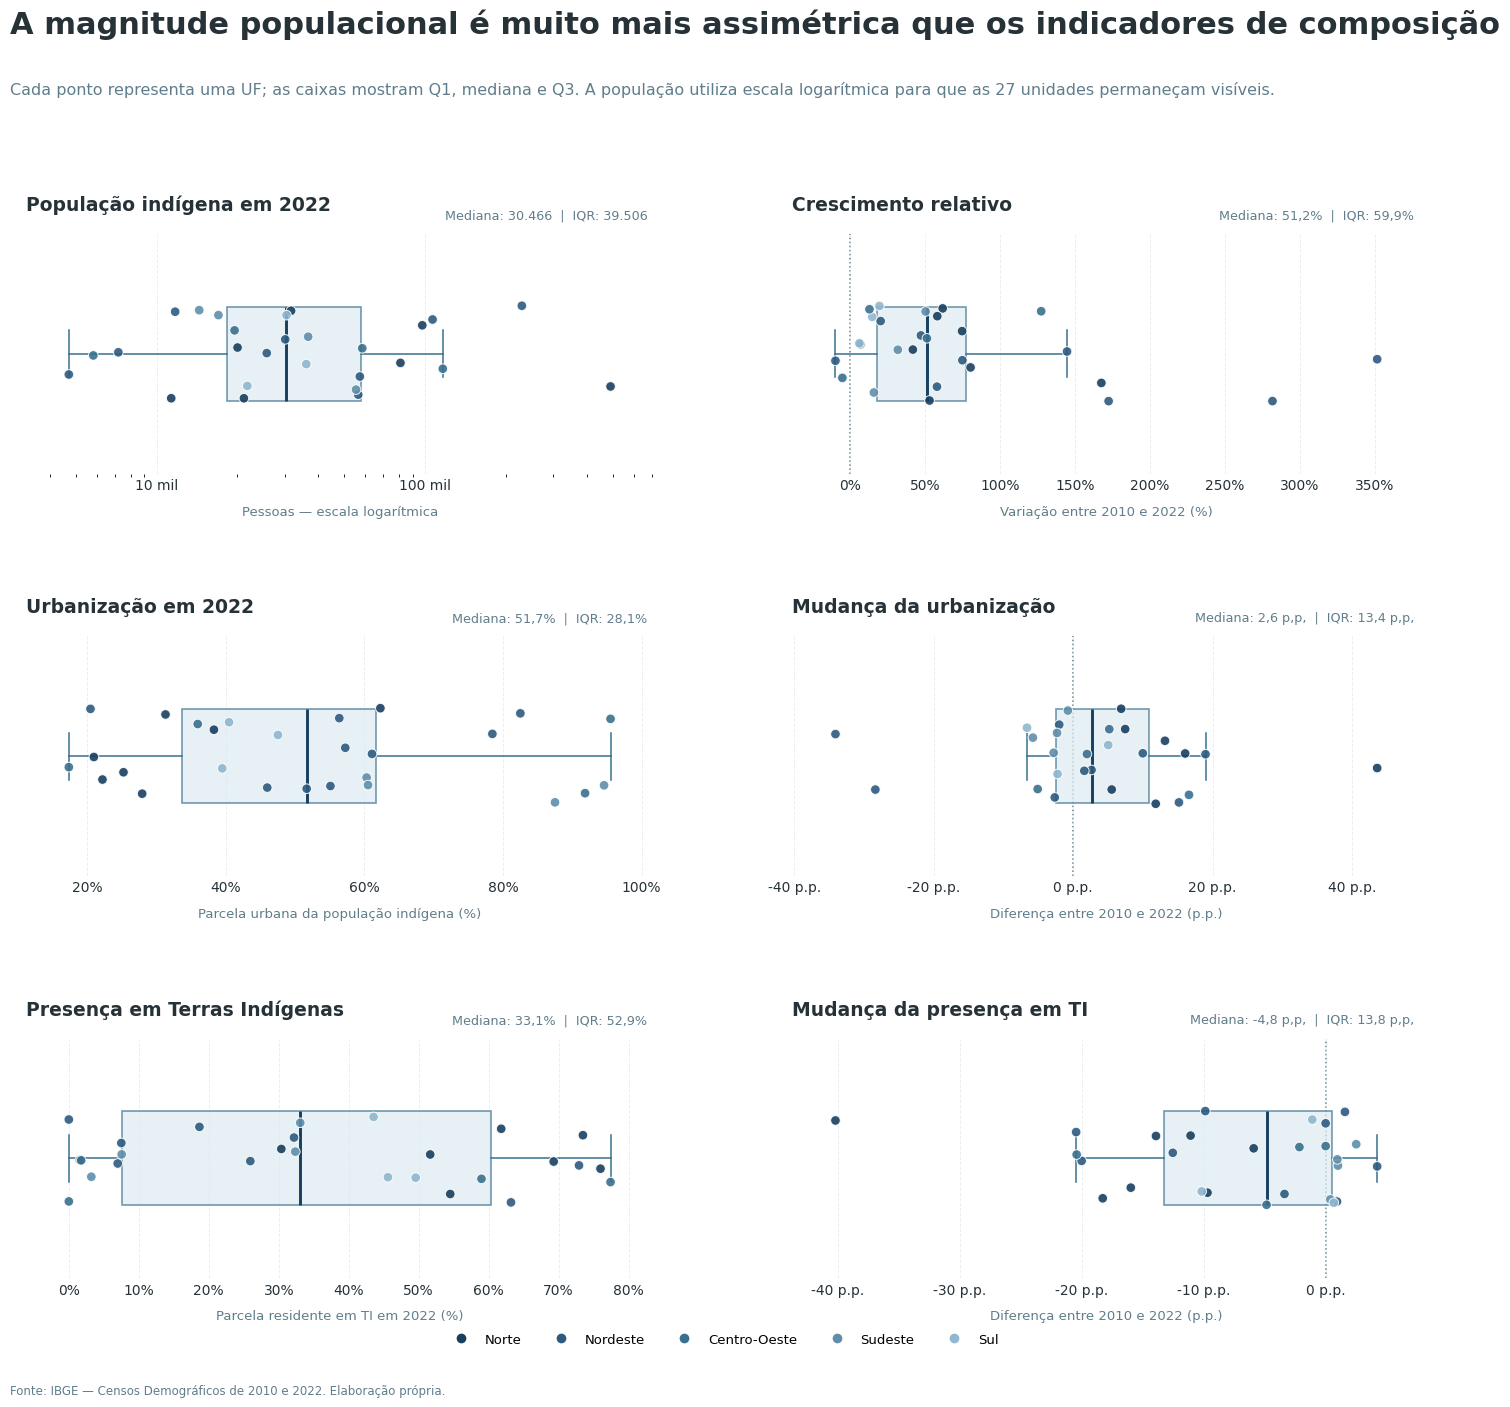

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_distribuicoes_estatisticas_estaduais.png')

In [12]:
graficos_estatisticos = PlotAnaliseEstatistica(
    df=df_estatistico,
    diretorio_saida=DIRETORIO_GRAFICOS,
)
caminho_grafico_distribuicoes = (
    graficos_estatisticos.plot_distribuicoes_estaduais()
)
caminho_grafico_distribuicoes

## 8. Quão concentrada é a população indígena entre as UFs?

A concentração é examinada por métricas complementares. CR3 e CR5 medem a participação das três e das cinco maiores UFs; o coeficiente de Gini resume o afastamento em relação à distribuição perfeitamente igual; o HHI enfatiza as maiores participações. O inverso do HHI produz o número efetivo de UFs de mesmo tamanho que geraria concentração equivalente.

In [13]:
medidas_concentracao = calcular_medidas_concentracao(df_estatistico)
curva_lorenz = calcular_curva_lorenz(
    df_estatistico["Indígenas 2022 Total"]
)
ranking_concentracao = (
    df_estatistico[["Localidade", "Indígenas 2022 Total"]]
    .sort_values("Indígenas 2022 Total", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

display(medidas_concentracao.round(4))
display(ranking_concentracao)

,Indicador,Total de UFs,População total,Gini,HHI,Número efetivo de UFs,CR3 (%),CR5 (%),UFs para alcançar 50%
0,Indígenas 2022 Total,27,1694836,0.58,0.12,8.06,49.38,61.43,4


,Localidade,Indígenas 2022 Total
0,Amazonas,490935
1,Bahia,229443
2,Mato Grosso do Sul,116469
3,Pernambuco,106646
4,Roraima,97668


### Resposta

A concentração é substancial. Amazonas, Bahia e Mato Grosso do Sul reúnem **49,4%** da população indígena brasileira da base; com Pernambuco e Roraima, a razão CR5 alcança **61,4%**. São necessárias apenas **quatro UFs** para ultrapassar metade do total nacional.

O coeficiente de Gini é **0,584** e o HHI, **0,124**. O número efetivo derivado do HHI é de aproximadamente **8,1 UFs**: embora o país possua 27 unidades, a concentração observada equivale à que existiria se o total estivesse igualmente distribuído entre pouco mais de oito unidades. As diferentes métricas convergem, portanto, para a mesma conclusão: a magnitude populacional está fortemente concentrada em uma parcela reduzida das UFs.

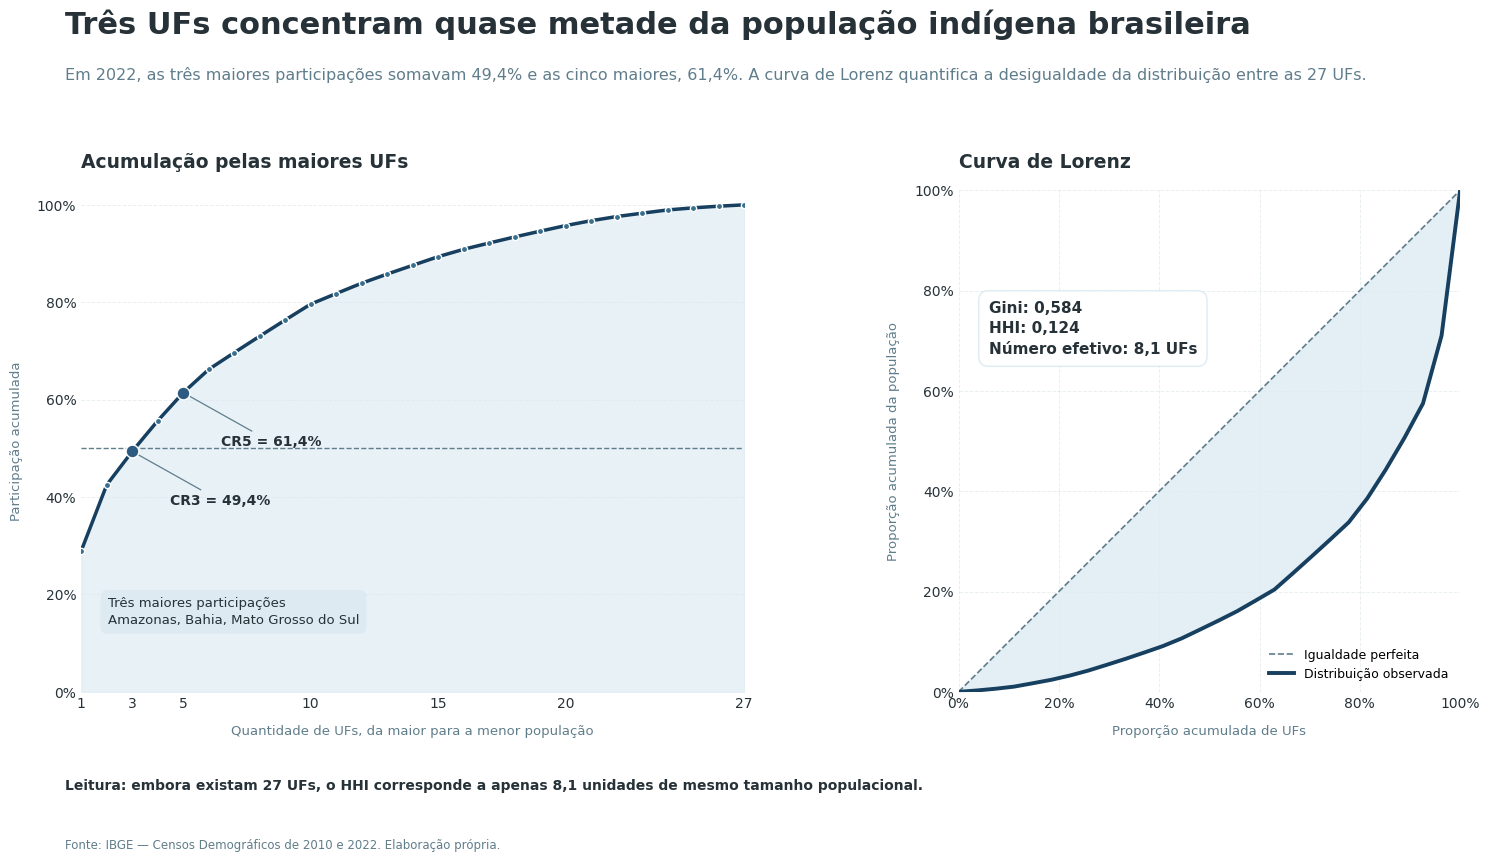

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_concentracao_estadual_2022.png')

In [14]:
caminho_grafico_concentracao = (
    graficos_estatisticos.plot_concentracao_estadual()
)
caminho_grafico_concentracao

## 9. Exportação das tabelas do Incremento 2

In [15]:
DIRETORIO_TABELAS.mkdir(parents=True, exist_ok=True)
resumo_distribuicoes.to_csv(
    CAMINHO_RESUMO_DISTRIBUICOES,
    index=False,
)
medidas_concentracao.to_csv(
    CAMINHO_MEDIDAS_CONCENTRACAO,
    index=False,
)
curva_lorenz.to_csv(
    CAMINHO_CURVA_LORENZ,
    index=False,
)

pd.Series(
    {
        "Resumo das distribuições": CAMINHO_RESUMO_DISTRIBUICOES,
        "Medidas de concentração": CAMINHO_MEDIDAS_CONCENTRACAO,
        "Curva de Lorenz": CAMINHO_CURVA_LORENZ,
    },
    name="Arquivo",
).to_frame()

,Arquivo
Resumo das distribuições,/home/lucas/workspace/pessoal/exploracao-dados...
Medidas de concentração,/home/lucas/workspace/pessoal/exploracao-dados...
Curva de Lorenz,/home/lucas/workspace/pessoal/exploracao-dados...


## Síntese do Incremento 2

1. A média estadual da população indígena não representa adequadamente uma UF central, pois a distribuição é fortemente assimétrica.
2. Urbanização e presença em TI apresentam grande heterogeneidade, mas não a mesma assimetria das contagens populacionais.
3. A concentração é confirmada simultaneamente por CR3, CR5, Gini, HHI e curva de Lorenz.
4. Medidas robustas e transformações de escala serão preservadas nas análises de relações e influência.

## 10. Quais UFs apresentam valores atípicos?

A sinalização combina dois critérios: a regra de Tukey, com limites de 1,5 IQR além dos quartis, e o escore robusto baseado na mediana e no MAD, com limite absoluto de 3,5. A união aumenta a transparência sobre desacordos entre métodos. Esses critérios descrevem afastamento estatístico e não comprovam erro de mensuração.

In [16]:
diagnostico_atipicidade = detectar_valores_atipicos(df_estatistico)
resumo_atipicidade = resumir_valores_atipicos(diagnostico_atipicidade)
ufs_sinalizadas = diagnostico_atipicidade.loc[
    diagnostico_atipicidade["Sinalizada"],
    [
        "Indicador",
        "Localidade",
        "Valor",
        "Escore robusto",
        "Concordância",
        "Direção",
    ],
]

display(resumo_atipicidade.drop(columns="Ordem do indicador"))
display(ufs_sinalizadas.round(2))

,Indicador,N,Sinalizadas por Tukey,Sinalizadas por MAD,Sinalizadas por ambos,Sinalizadas pela união,UFs sinalizadas
0,Indígenas 2022 Total,27,2,2,2,2,Amazonas; Bahia
1,Crescimento relativo (%),27,4,2,2,4,Rio Grande do Norte; Bahia; Ceará; Amazonas
2,Urbanização 2022 (%),27,0,0,0,0,Nenhuma
3,Mudança na urbanização (p.p.),27,3,3,3,3,Amazonas; Rio Grande do Norte; Piauí
4,Presença em TI 2022 (%),27,0,0,0,0,Nenhuma
5,Mudança na presença em TI (p.p.),27,1,1,1,1,Amazonas


,Indicador,Localidade,Valor,Escore robusto,Concordância,Direção
0,Indígenas 2022 Total,Amazonas,490935.00,16.23,Ambos os critérios,Superior
1,Indígenas 2022 Total,Bahia,229443.00,7.01,Ambos os critérios,Superior
27,Crescimento relativo (%),Rio Grande do Norte,351.44,6.40,Ambos os critérios,Superior
28,Crescimento relativo (%),Bahia,281.64,4.91,Ambos os critérios,Superior
29,Crescimento relativo (%),Ceará,172.37,2.58,Somente Tukey,Superior
30,Crescimento relativo (%),Amazonas,167.52,2.48,Somente Tukey,Superior
81,Mudança na urbanização (p.p.),Amazonas,43.60,5.08,Ambos os critérios,Superior
82,Mudança na urbanização (p.p.),Rio Grande do Norte,-34.12,-4.55,Ambos os critérios,Inferior
83,Mudança na urbanização (p.p.),Piauí,-28.39,-3.85,Ambos os critérios,Inferior
135,Mudança na presença em TI (p.p.),Amazonas,-40.22,-4.11,Ambos os critérios,Inferior


### Resposta

Na população total de 2022, **Amazonas e Bahia** são sinalizados simultaneamente por Tukey e mediana/MAD. No crescimento relativo, **Rio Grande do Norte e Bahia** satisfazem os dois critérios, enquanto **Ceará e Amazonas** são identificados apenas por Tukey. Não há sinalização para o nível de urbanização nem para a proporção residente em Terras Indígenas em 2022.

Nas mudanças de composição, **Amazonas, Rio Grande do Norte e Piauí** são sinalizados pelos dois critérios para urbanização; Amazonas também é o único caso sinalizado na mudança da presença em TI. Como a base passou pelas identidades de totais, pela coerência dos indicadores derivados e pela comparação com a fonte, as sinalizações não constituem evidência de erro de processamento. Elas são tratadas como fenômenos substantivos que exigem interpretação e análise de influência.

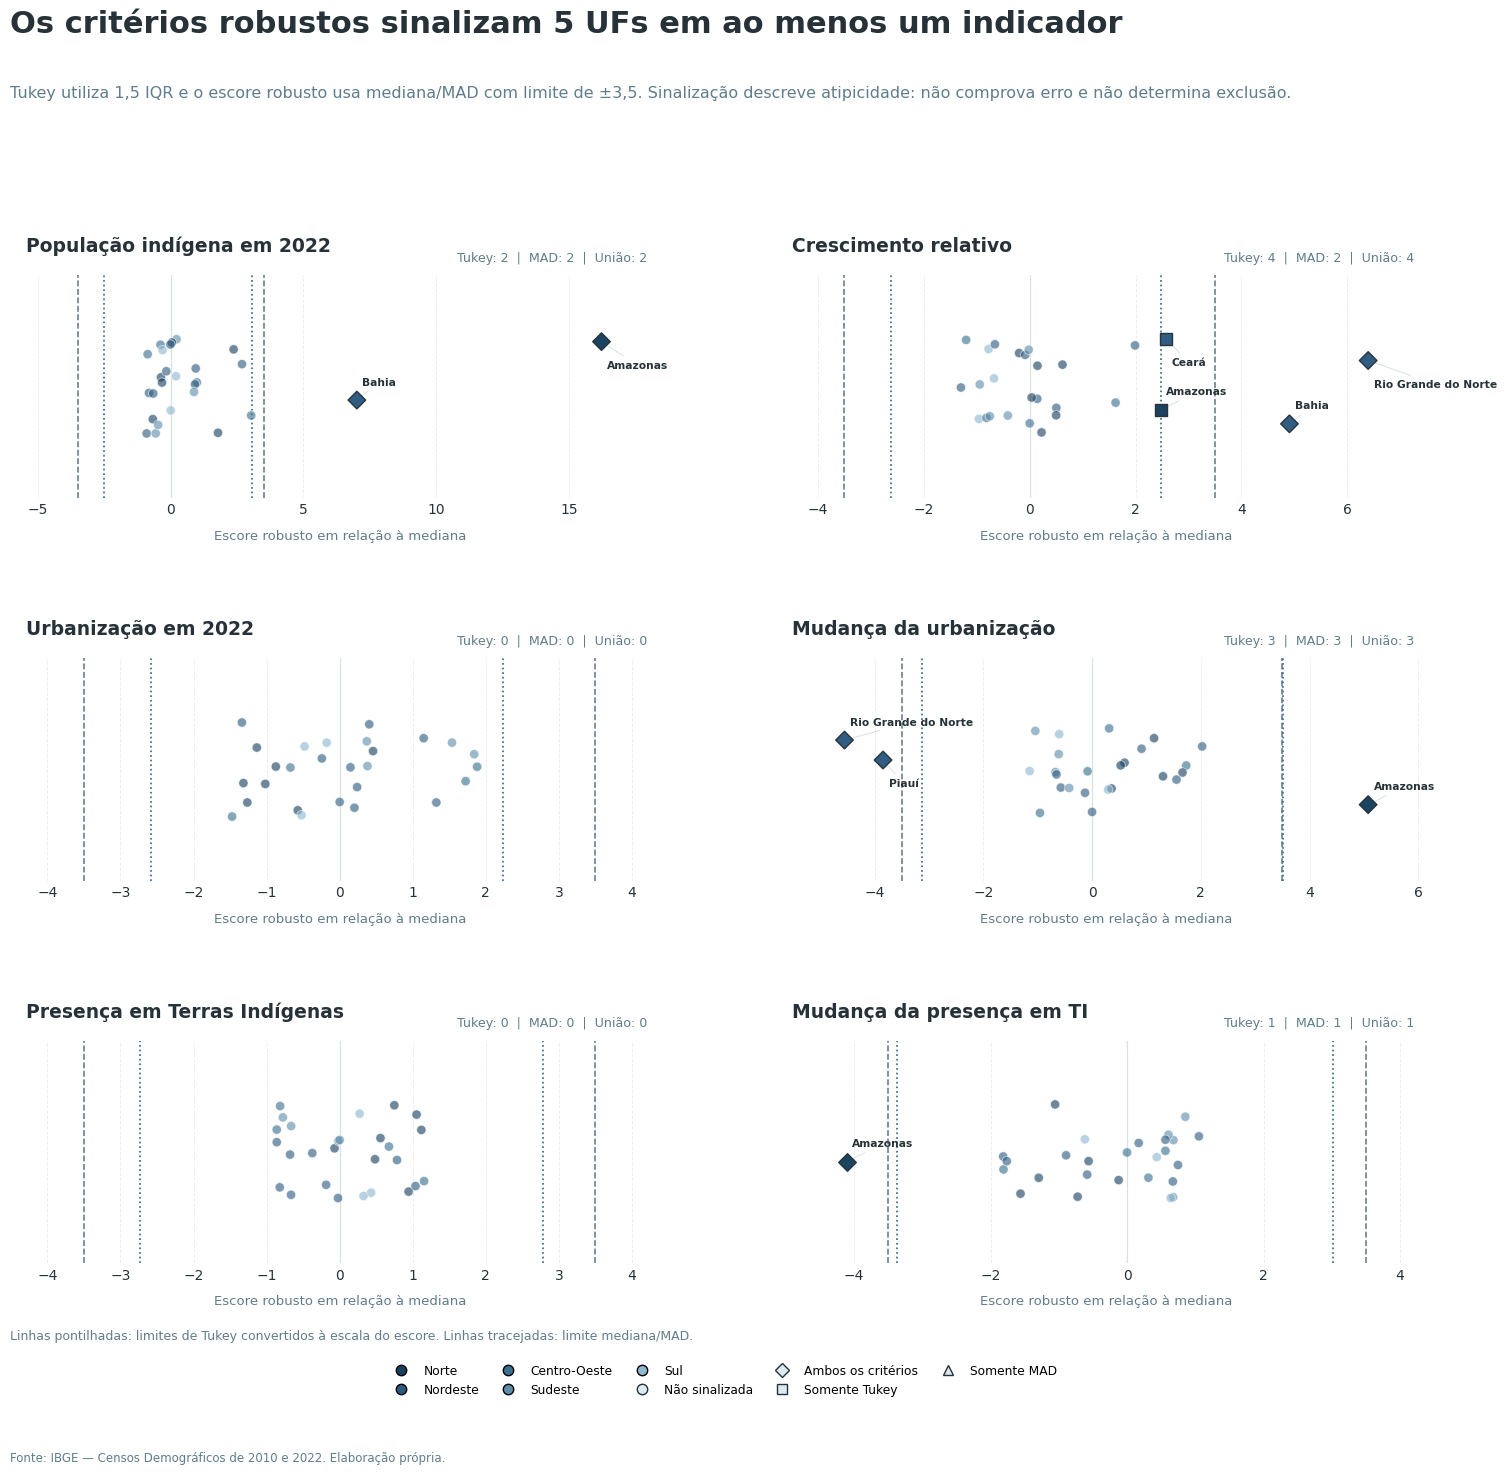

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_valores_atipicos_estaduais.png')

In [17]:
caminho_grafico_atipicidade = (
    graficos_estatisticos.plot_valores_atipicos_estaduais()
)
caminho_grafico_atipicidade

## 11. A sinalização depende da escala?

Contagens populacionais e taxas de crescimento apresentam assimetria. Por isso, a análise compara a classificação na escala original com as transformações logarítmicas já previstas no contrato analítico. A comparação não escolhe automaticamente uma escala correta; ela documenta quais conclusões são sensíveis à representação da variável.

In [18]:
sensibilidade_escala = comparar_sensibilidade_escala(df_estatistico)
sensibilidade_escala.loc[
    sensibilidade_escala["Mudou com a transformação"]
]

,Dimensão,Localidade,Região,Indicador original,Indicador transformado,Sinalizada na escala original,Sinalizada na escala transformada,Mudou com a transformação,Resultado
1,Magnitude populacional,Bahia,Nordeste,Indígenas 2022 Total,População 2022 (log10),True,False,True,Deixou de ser sinalizada
29,Crescimento populacional,Ceará,Nordeste,Crescimento relativo (%),Crescimento logarítmico,True,False,True,Deixou de ser sinalizada
30,Crescimento populacional,Amazonas,Norte,Crescimento relativo (%),Crescimento logarítmico,True,False,True,Deixou de ser sinalizada


### Resposta

A transformação logarítmica preserva Amazonas como valor atípico de magnitude, mas **Bahia deixa de ser sinalizada**. No crescimento, **Ceará e Amazonas deixam de ser sinalizados** na escala logarítmica, enquanto Bahia e Rio Grande do Norte permanecem. Portanto, parte da atipicidade observada nas escalas originais decorre da assimetria das distribuições; os casos persistentes nas duas escalas possuem evidência descritiva mais estável.

## 12. Quais UFs exercem maior influência sobre as medidas?

A influência é examinada por exclusões unitárias hipotéticas (*leave-one-out*). Para cada UF, média, mediana, Gini, HHI e CR3 são recalculados sem aquela observação. A ordenação usa a maior variação relativa absoluta entre as cinco medidas e funciona apenas como diagnóstico de sensibilidade.

In [19]:
influencia_leave_one_out = calcular_influencia_leave_one_out(
    df_estatistico
)
sensibilidade_sem_sinalizadas = calcular_sensibilidade_sem_sinalizadas(
    df_estatistico,
    diagnostico_atipicidade,
)

display(influencia_leave_one_out.head(10).round(2))
display(
    sensibilidade_sem_sinalizadas[
        [
            "Indicador",
            "Quantidade de UFs sinalizadas",
            "Variação da média (%)",
            "Variação da mediana (%)",
        ]
    ].round(2)
)

,UF retirada hipoteticamente,Região,População da UF,Participação da UF (%),Média sem UF,Variação da média (%),Mediana sem UF,Variação da mediana (%),Gini sem UF,Variação do Gini (%),HHI sem UF,Variação do HHI (%),CR3 sem UF (%),Variação do CR3 (%),Variação do CR3 (p.p.),Variação máxima absoluta (%),Métrica de maior variação,Rank de influência
0,Amazonas,Norte,490935,28.97,46303.88,-26.23,30303.00,-0.54,0.48,-17.03,0.08,-35.86,37.59,-23.87,-11.79,35.86,HHI,1
1,Bahia,Nordeste,229443,13.54,56361.27,-10.21,30303.00,-0.54,0.57,-2.46,0.14,14.00,48.73,-1.31,-0.65,14.00,HHI,2
2,Mato Grosso do Sul,Centro-Oeste,116469,6.87,60706.42,-3.29,30303.00,-0.54,0.59,1.40,0.14,10.91,52.40,6.12,3.02,10.91,HHI,3
3,Pernambuco,Nordeste,106646,6.29,61084.23,-2.69,30303.00,-0.54,0.59,1.62,0.14,10.25,52.69,6.71,3.32,10.25,HHI,4
4,Roraima,Norte,97668,5.76,61429.54,-2.14,30303.00,-0.54,0.59,1.76,0.14,9.59,52.40,6.12,3.02,9.59,HHI,5
5,Pará,Norte,80980,4.78,62071.38,-1.12,30303.00,-0.54,0.60,1.86,0.13,8.26,51.85,5.02,2.48,8.26,HHI,6
6,Mato Grosso,Centro-Oeste,58356,3.44,62941.54,0.27,30303.00,-0.54,0.59,1.82,0.13,6.23,51.14,3.57,1.76,6.23,HHI,7
7,Maranhão,Nordeste,57166,3.37,62987.31,0.34,30303.00,-0.54,0.59,1.81,0.13,6.12,51.10,3.49,1.72,6.12,HHI,8
8,Ceará,Nordeste,56372,3.33,63017.85,0.39,30303.00,-0.54,0.59,1.79,0.13,6.05,51.08,3.44,1.70,6.05,HHI,9
9,São Paulo,Sudeste,55331,3.26,63057.88,0.46,30303.00,-0.54,0.59,1.76,0.13,5.95,51.04,3.37,1.67,5.95,HHI,10


,Indicador,Quantidade de UFs sinalizadas,Variação da média (%),Variação da mediana (%)
0,Indígenas 2022 Total,2,-37.90,-1.07
1,Crescimento relativo (%),4,-39.45,-7.80
2,Urbanização 2022 (%),0,0.00,0.00
3,Mudança na urbanização (p.p.),3,36.49,45.39
4,Presença em TI 2022 (%),0,0.00,0.00
5,Mudança na presença em TI (p.p.),1,-16.25,-15.17


### Resposta

**Amazonas é a observação de maior influência**. A UF reúne 29,0% do total de 2022; sua retirada hipotética reduziria a média em 26,2%, o Gini em 17,0%, o HHI em 35,9% e o CR3 em 23,9%, mas alteraria a mediana em apenas 0,5%. Essa diferença confirma que a mediana é muito mais estável que a média diante da maior UF.

Quando Amazonas e Bahia — as duas UFs sinalizadas na população total — são retiradas apenas para sensibilidade, a média cai **37,9%**, enquanto a mediana varia somente **1,1%**. No crescimento relativo, a retirada hipotética das quatro UFs sinalizadas reduz a média em 39,5% e a mediana em 7,8%. Assim, os valores atípicos são influentes sobretudo sobre medidas clássicas e de concentração, mas não invalidam a base nem justificam exclusão automática.

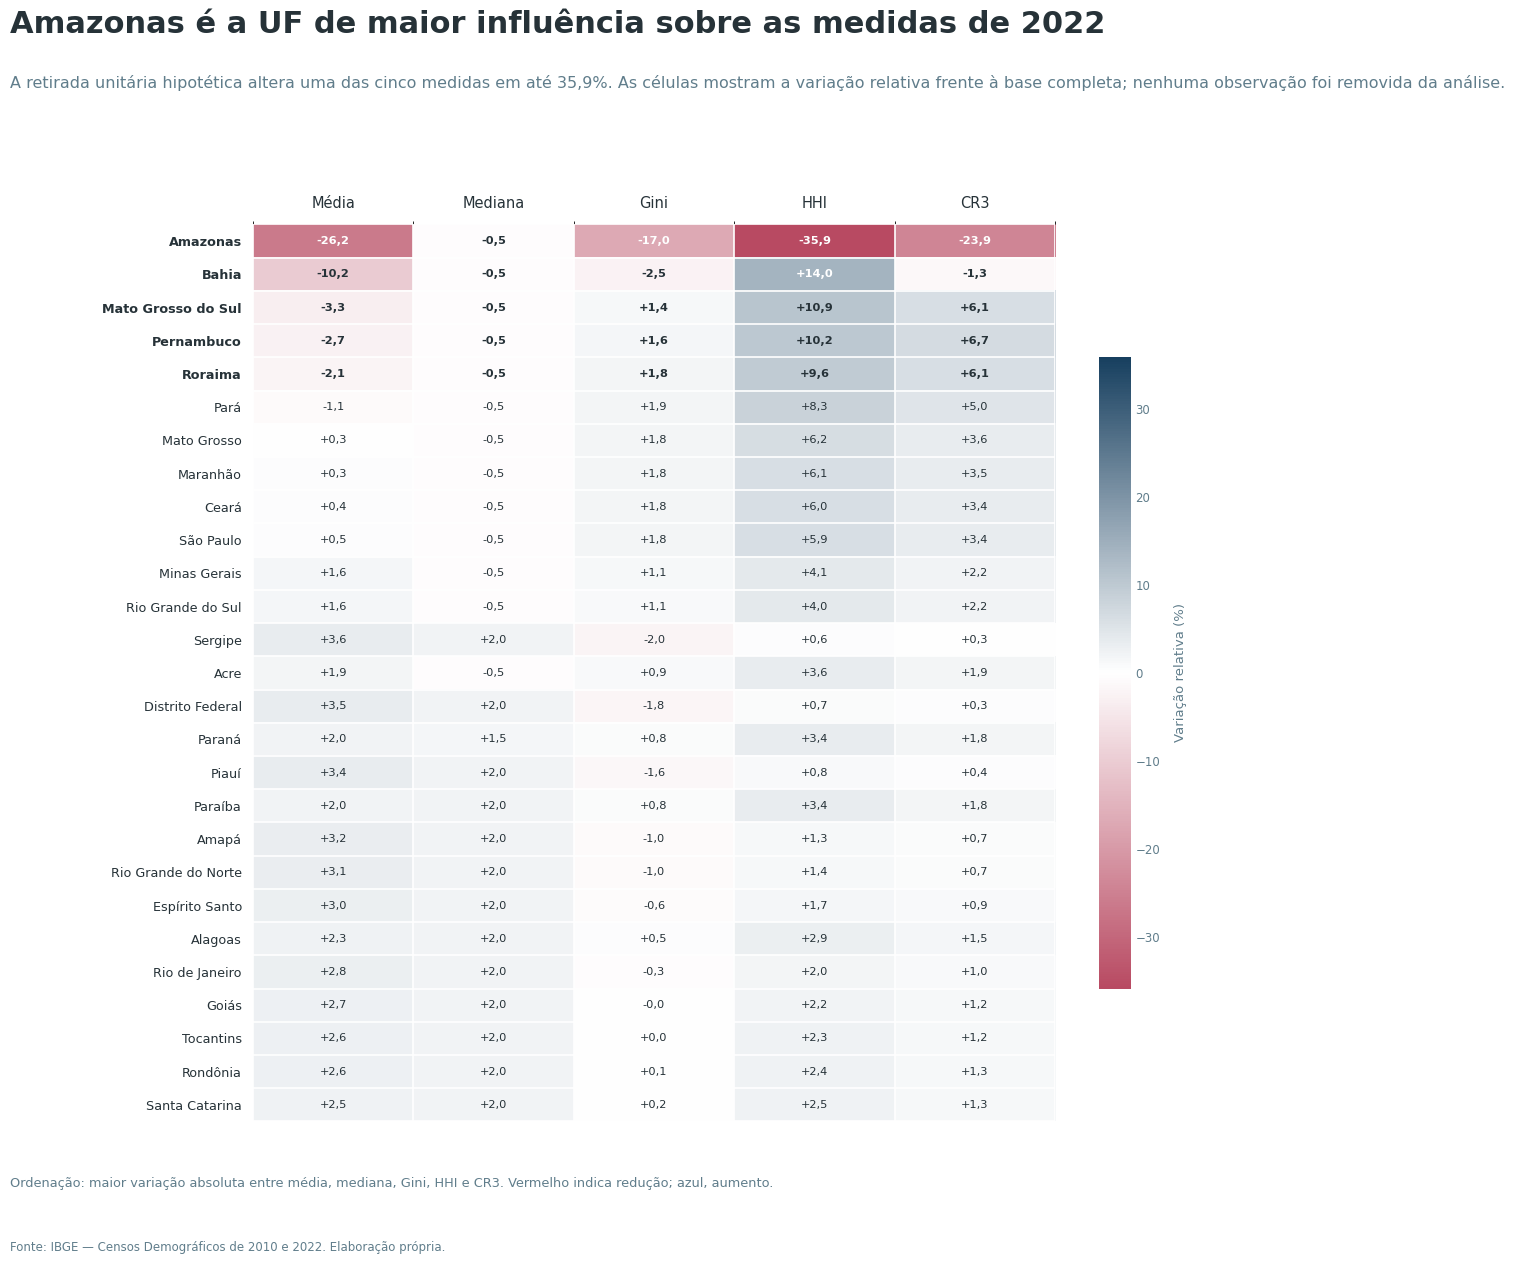

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_influencia_estadual_2022.png')

In [20]:
caminho_grafico_influencia = (
    graficos_estatisticos.plot_influencia_estadual()
)
caminho_grafico_influencia

## 13. Exportação das tabelas do Incremento 3

In [21]:
diagnostico_atipicidade.to_csv(
    CAMINHO_DIAGNOSTICO_ATIPICOS, index=False
)
resumo_atipicidade.to_csv(CAMINHO_RESUMO_ATIPICOS, index=False)
sensibilidade_escala.to_csv(CAMINHO_SENSIBILIDADE_ESCALA, index=False)
influencia_leave_one_out.to_csv(CAMINHO_INFLUENCIA, index=False)
sensibilidade_sem_sinalizadas.to_csv(
    CAMINHO_SENSIBILIDADE_SEM_SINALIZADAS, index=False
)

pd.Series(
    {
        "Diagnóstico de valores atípicos": CAMINHO_DIAGNOSTICO_ATIPICOS,
        "Resumo de valores atípicos": CAMINHO_RESUMO_ATIPICOS,
        "Sensibilidade à escala": CAMINHO_SENSIBILIDADE_ESCALA,
        "Influência leave-one-out": CAMINHO_INFLUENCIA,
        "Sensibilidade sem sinalizadas": (
            CAMINHO_SENSIBILIDADE_SEM_SINALIZADAS
        ),
    },
    name="Arquivo",
).to_frame()

,Arquivo
Diagnóstico de valores atípicos,/home/lucas/workspace/pessoal/exploracao-dados...
Resumo de valores atípicos,/home/lucas/workspace/pessoal/exploracao-dados...
Sensibilidade à escala,/home/lucas/workspace/pessoal/exploracao-dados...
Influência leave-one-out,/home/lucas/workspace/pessoal/exploracao-dados...
Sensibilidade sem sinalizadas,/home/lucas/workspace/pessoal/exploracao-dados...


## Síntese do Incremento 3

1. Cinco UFs são sinalizadas em ao menos um dos seis indicadores, com diferentes níveis de concordância entre Tukey e mediana/MAD.
2. Nenhum caso é classificado como erro: as validações e identidades da base permanecem aprovadas.
3. A transformação logarítmica altera três classificações, evidenciando sensibilidade à escala.
4. Amazonas é simultaneamente atípico e influente, sobretudo sobre HHI, média e concentração.
5. A mediana permanece muito mais estável que a média; nenhuma UF foi removida da camada analítica.

## 14. Como os indicadores estaduais se relacionam?

Os pares foram definidos por justificativa substantiva, e não por uma matriz exaustiva. Totais não são correlacionados com seus próprios componentes, proporções complementares são excluídas e mudanças não são comparadas com identidades algébricas das quais derivam.

O coeficiente de Spearman é adotado por medir associações monotônicas entre postos, com menor dependência de linearidade e escala. Como as 27 UFs constituem o universo territorial analisado, os coeficientes são apresentados sem valores-p ou inferência para uma população hipotética de estados.


In [22]:
correlacoes_spearman = calcular_correlacoes_spearman(
    df_estatistico
)
correlacoes_spearman[
    [
        "Relação",
        "N",
        "Ausentes pareados",
        "Spearman (ρ)",
        "Direção",
    ]
].round(3)


,Relação,N,Ausentes pareados,Spearman (ρ),Direção
0,Persistência da magnitude populacional,27,0,0.97,Positiva
1,Magnitude populacional × urbanização em 2022,27,0,-0.23,Negativa
2,Magnitude populacional × presença em TI em 2022,27,0,0.37,Positiva
3,Crescimento × mudança da urbanização,27,0,0.34,Positiva
4,Crescimento × mudança da presença em TI,27,0,-0.31,Negativa
5,Urbanização × presença em TI em 2022,27,0,-0.83,Negativa
6,Urbanização em TI × fora de TI em 2022,25,2,-0.18,Negativa


### Resposta

A hierarquia de magnitude é altamente persistente: a correlação entre as populações estaduais de 2010 e 2022 alcança **ρ = 0,967**. A relação substantiva de maior magnitude ocorre entre urbanização e presença em Terras Indígenas em 2022 (**ρ = −0,832**): UFs com maior participação urbana tendem a apresentar menor proporção residente em TI. Trata-se de associação ecológica, que não descreve indivíduos nem estabelece causalidade.

As demais relações são menos intensas. A magnitude populacional se associa negativamente à urbanização (**ρ = −0,235**) e positivamente à presença em TI (**ρ = 0,369**). O crescimento apresenta associação positiva com a mudança da urbanização (**ρ = 0,335**) e negativa com a mudança da presença em TI (**ρ = −0,314**). Já a urbanização dentro e fora de TI possui **ρ = −0,176**, calculado sobre 25 UFs devido às duas ausências estruturais previamente documentadas.

Os sinais distintos mostram que crescimento, urbanização e presença em TI não podem ser condensados em uma única trajetória estadual.


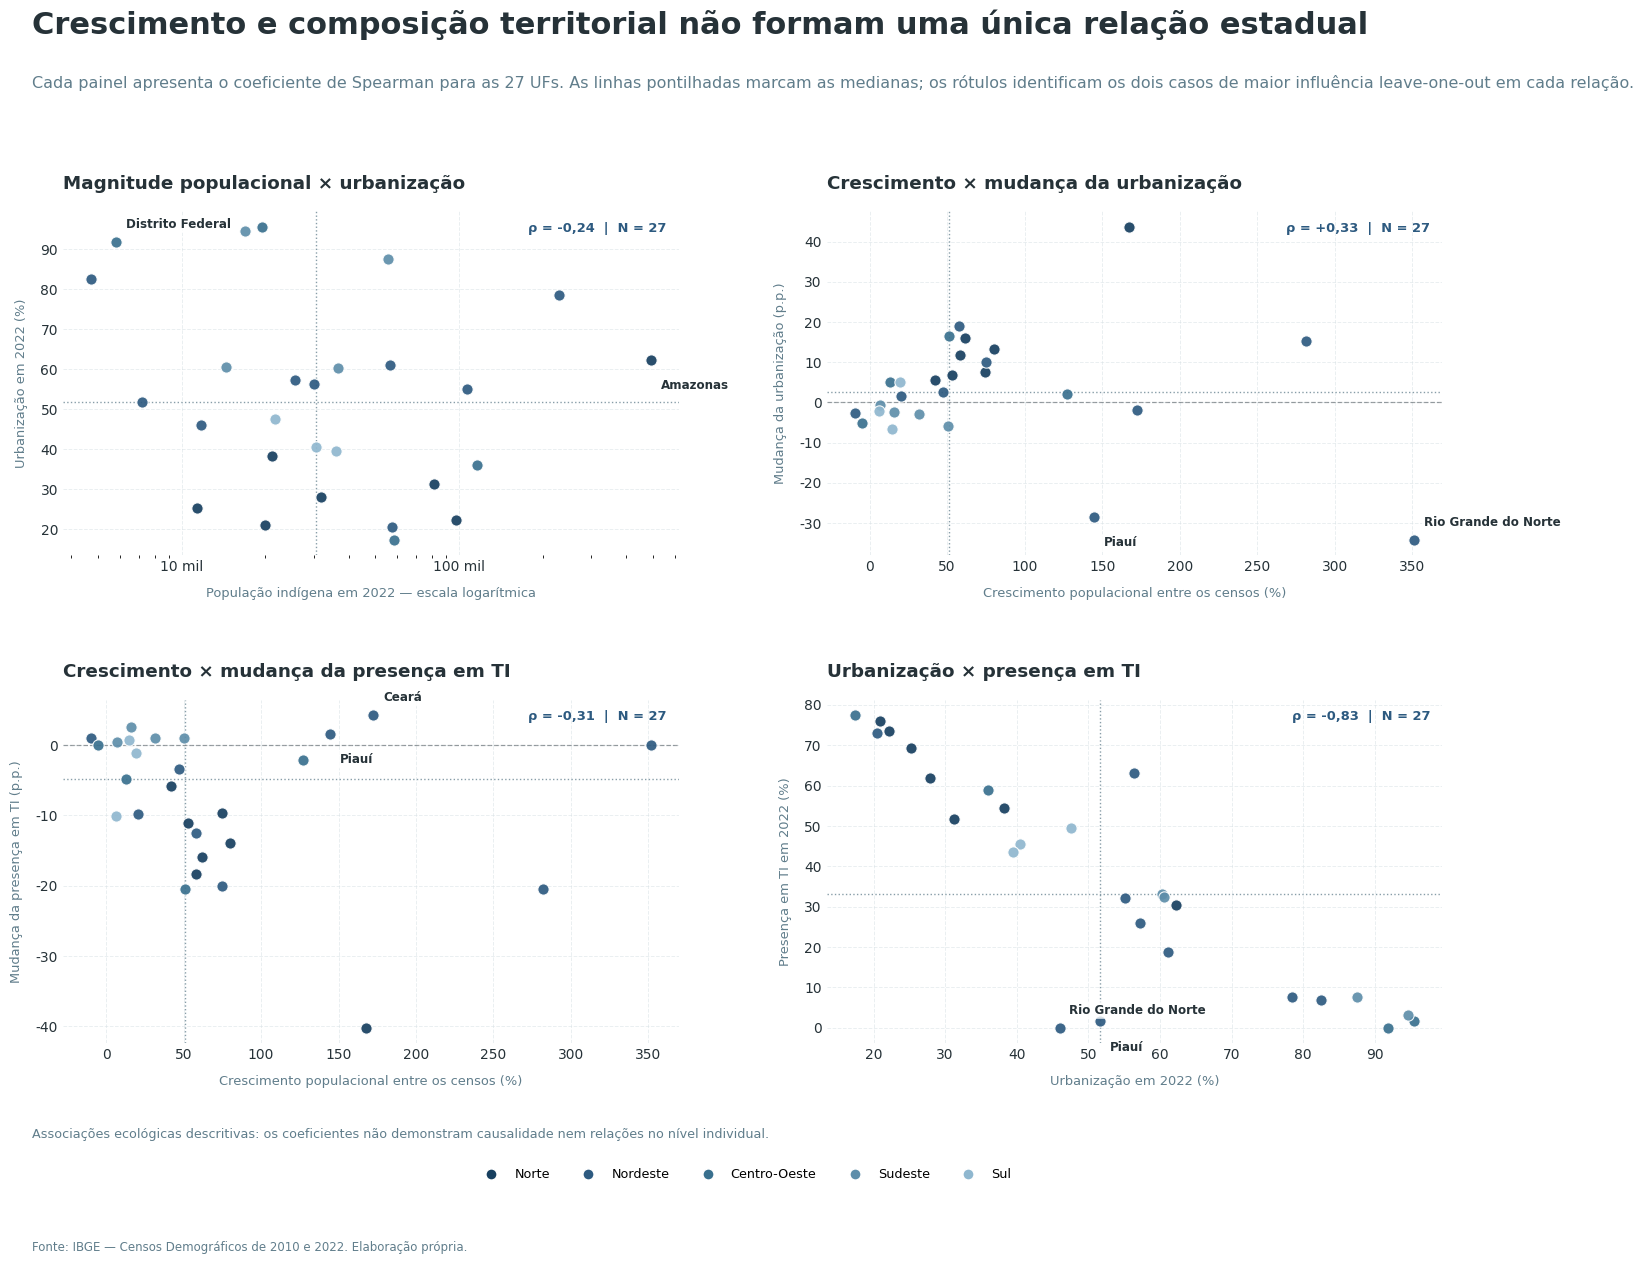

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_relacoes_estaduais_spearman.png')

In [23]:
caminho_grafico_relacoes = (
    graficos_estatisticos.plot_relacoes_estaduais_spearman()
)
caminho_grafico_relacoes


## 15. A ordenação populacional das UFs permaneceu estável?

A estabilidade é avaliada pela correlação de Spearman entre os rankings de 2010 e 2022, pela retenção dos grupos Top 5 e Top 10 e pela mudança absoluta de posição de cada UF. O rank 1 identifica a maior população estadual em cada censo.


In [24]:
ranking_populacional = calcular_estabilidade_ranking_populacional(
    df_estatistico
)
resumo_ranking = resumir_estabilidade_ranking(
    ranking_populacional
)
maiores_movimentos = ranking_populacional.nlargest(
    10,
    "Mudança absoluta (posições)",
)

display(resumo_ranking.round(3))
display(
    maiores_movimentos[
        [
            "Localidade",
            "Região",
            "Posição em 2010",
            "Posição em 2022",
            "Variação no ranking (posições)",
            "Movimento",
        ]
    ]
)


,Total de UFs,Spearman entre rankings (ρ),UFs na mesma posição,Mediana da mudança absoluta,Média da mudança absoluta,Máxima mudança absoluta,UFs com maior mudança,UFs que mais subiram,Posições da maior subida,UFs que mais desceram,Posições da maior queda,Interseção Top 5,Retenção Top 5 (%),Interseção Top 10,Retenção Top 10 (%)
0,27,0.97,4,2.00,1.63,5,Ceará,Ceará,5,Rio de Janeiro,3,5,100.00,9,90.00


,Localidade,Região,Posição em 2010,Posição em 2022,Variação no ranking (posições),Movimento
8,Ceará,Nordeste,14,9,5,Subiu
22,Rio Grande do Norte,Nordeste,27,23,4,Subiu
12,Acre,Norte,16,13,3,Subiu
20,Rio de Janeiro,Sudeste,18,21,-3,Desceu
1,Bahia,Nordeste,4,2,2,Subiu
9,São Paulo,Sudeste,8,10,-2,Desceu
11,Rio Grande do Sul,Sul,10,12,-2,Desceu
13,Paraná,Sul,12,14,-2,Desceu
14,Paraíba,Nordeste,13,15,-2,Desceu
16,Santa Catarina,Sul,15,17,-2,Desceu


### Resposta

A ordenação permaneceu amplamente estável. A correlação entre os rankings é **ρ = 0,967**, os cinco primeiros lugares preservam **100%** de seus integrantes e o Top 10 retém **90%**. A mudança absoluta mediana foi de apenas **2 posições**, embora somente quatro UFs tenham permanecido exatamente na mesma colocação.

As principais alterações ocorreram fora do topo. **Ceará** subiu cinco posições, do 14.º para o 9.º lugar; **Rio Grande do Norte** avançou quatro, do 27.º para o 23.º; e **Acre** subiu três, do 16.º para o 13.º. A maior queda foi a do **Rio de Janeiro**, que passou do 18.º para o 21.º lugar. Portanto, a estrutura geral persistiu, mas comportou rearranjos estaduais relevantes.


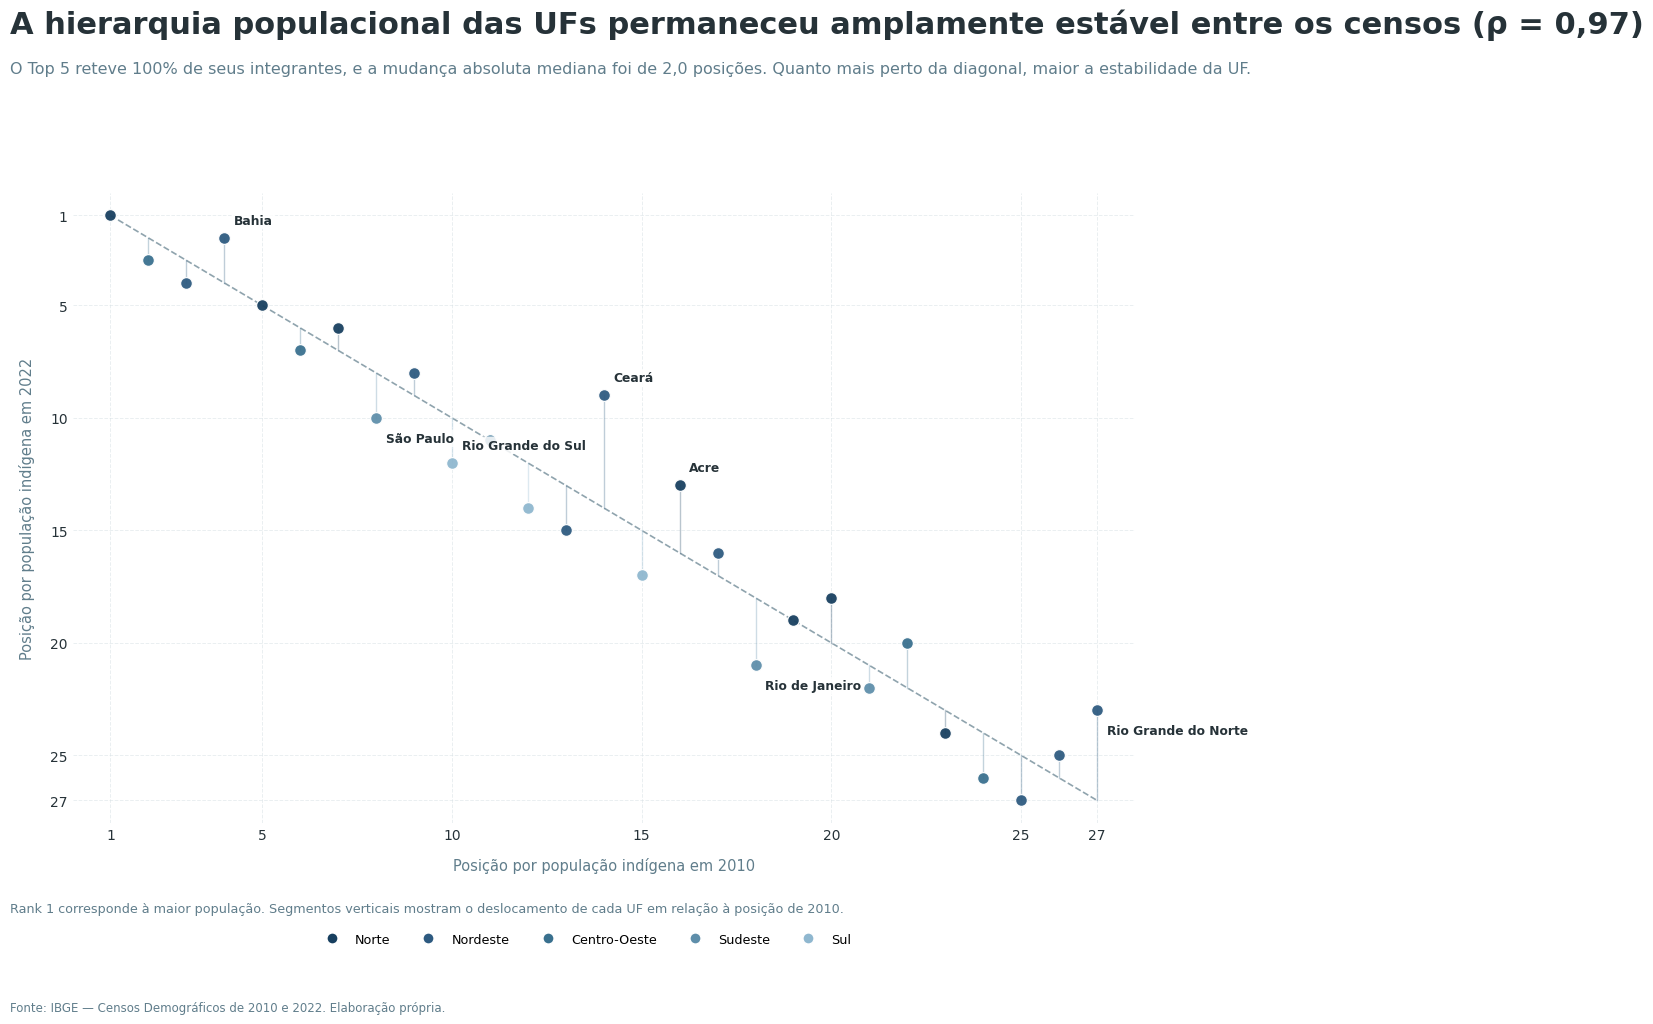

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_estabilidade_ranking_populacional_2010_2022.png')

In [25]:
caminho_grafico_ranking = (
    graficos_estatisticos.plot_estabilidade_ranking_populacional()
)
caminho_grafico_ranking


## 16. As associações dependem excessivamente de alguma UF?

Cada correlação é recalculada após a retirada hipotética de uma UF por vez. A diferença entre o coeficiente completo e o coeficiente *leave-one-out* mede influência descritiva; nenhuma observação é efetivamente removida da base.


In [26]:
influencia_correlacoes = (
    calcular_influencia_correlacoes_leave_one_out(
        df_estatistico
    )
)
casos_mais_influentes = influencia_correlacoes.loc[
    influencia_correlacoes[
        "Rank de influência na relação"
    ].le(2)
]

casos_mais_influentes[
    [
        "Relação",
        "UF retirada hipoteticamente",
        "Spearman completo (ρ)",
        "Spearman sem UF (ρ)",
        "Variação de ρ",
        "Rank de influência na relação",
    ]
].round(3)


,Relação,UF retirada hipoteticamente,Spearman completo (ρ),Spearman sem UF (ρ),Variação de ρ,Rank de influência na relação
0,Persistência da magnitude populacional,Ceará,0.97,0.97,0.01,1
1,Persistência da magnitude populacional,Amazonas,0.97,0.96,-0.00,2
27,Magnitude populacional × urbanização em 2022,Distrito Federal,-0.23,-0.15,0.08,1
28,Magnitude populacional × urbanização em 2022,Amazonas,-0.23,-0.32,-0.08,2
54,Magnitude populacional × presença em TI em 2022,Amapá,0.37,0.45,0.08,1
55,Magnitude populacional × presença em TI em 2022,Distrito Federal,0.37,0.30,-0.07,2
81,Crescimento × mudança da urbanização,Rio Grande do Norte,0.34,0.49,0.16,1
82,Crescimento × mudança da urbanização,Piauí,0.34,0.46,0.12,2
108,Crescimento × mudança da presença em TI,Ceará,-0.31,-0.45,-0.14,1
109,Crescimento × mudança da presença em TI,Piauí,-0.31,-0.42,-0.11,2


### Resposta

A persistência da magnitude é especialmente robusta: mesmo a retirada hipotética do caso mais influente, Ceará, altera **ρ** em apenas **0,008**. Nas relações de mudança, a sensibilidade é maior. Sem o Rio Grande do Norte, a associação entre crescimento e mudança da urbanização passa de **0,335** para **0,495**, diferença de **0,160**; sem Ceará, a relação entre crescimento e mudança da presença em TI passa de **−0,314** para **−0,449**, diferença de **−0,135**.

Esses resultados qualificam a interpretação: a estabilidade hierárquica não depende de uma única UF, ao passo que algumas associações de mudança são mais sensíveis a casos específicos. Ainda assim, influência não equivale a erro e não justifica exclusão automática.


## 17. Exportação das tabelas do Incremento 4


In [27]:
correlacoes_spearman.to_csv(
    CAMINHO_CORRELACOES_SPEARMAN, index=False
)
ranking_populacional.to_csv(
    CAMINHO_RANKING_POPULACIONAL, index=False
)
resumo_ranking.to_csv(CAMINHO_RESUMO_RANKING, index=False)
influencia_correlacoes.to_csv(
    CAMINHO_INFLUENCIA_CORRELACOES, index=False
)

pd.Series(
    {
        "Correlações de Spearman": CAMINHO_CORRELACOES_SPEARMAN,
        "Estabilidade do ranking": CAMINHO_RANKING_POPULACIONAL,
        "Resumo da estabilidade": CAMINHO_RESUMO_RANKING,
        "Influência nas correlações": CAMINHO_INFLUENCIA_CORRELACOES,
    },
    name="Arquivo",
).to_frame()


,Arquivo
Correlações de Spearman,/home/lucas/workspace/pessoal/exploracao-dados...
Estabilidade do ranking,/home/lucas/workspace/pessoal/exploracao-dados...
Resumo da estabilidade,/home/lucas/workspace/pessoal/exploracao-dados...
Influência nas correlações,/home/lucas/workspace/pessoal/exploracao-dados...


## Síntese do Incremento 4

1. A hierarquia populacional estadual é altamente persistente entre 2010 e 2022, com correlação de postos de 0,967.

2. Urbanização e presença em TI formam a associação substantiva mais intensa e negativa, sem implicação causal ou individual.

3. Crescimento, mudança da urbanização e mudança da presença em TI apresentam associações de sinais distintos e não constituem uma trajetória única.

4. O Top 5 foi integralmente preservado e o Top 10 reteve nove UFs, embora Ceará e Rio Grande do Norte tenham avançado de forma expressiva.

5. As relações de mudança são mais sensíveis a casos específicos que a estabilidade da magnitude, mas nenhuma UF foi removida.


## 18. Quais eixos sintetizam os perfis estaduais?

A análise multivariada utiliza seis dimensões não redundantes: magnitude populacional em 2022, crescimento entre os censos, urbanização em 2022, mudança da urbanização, presença em TI em 2022 e mudança da presença em TI. Magnitude e crescimento entram em escala logarítmica, reduzindo a dominância de valores extremos sem apagar sua posição relativa.

Antes da PCA, cada dimensão é centralizada por sua mediana e dividida pelo intervalo interquartil. Essa padronização robusta torna unidades distintas comparáveis e diminui a dependência da média e do desvio-padrão em um universo de apenas 27 UFs. Retém-se o menor número de componentes capaz de explicar ao menos 80% da variação total.


In [28]:
df_multivariado = preparar_base_multivariada(
    df_estatistico
)
resultado_pca = calcular_pca_multivariada(df_estatistico)
variancia_pca = resultado_pca["variancia"]
cargas_pca = resultado_pca["cargas"]
escores_pca = resultado_pca["escores"]
quantidade_componentes = resultado_pca[
    "quantidade_componentes_retidos"
]

display(variancia_pca.round(3))
display(
    cargas_pca.loc[
        cargas_pca["Componente retido"],
        [
            "Componente",
            "Variável",
            "Correlação variável–componente",
            "Contribuição ao componente (%)",
        ],
    ].round(3)
)


,Componente,Autovalor,Variância explicada (%),Variância acumulada (%),Componente retido
0,PC1,2.26,49.47,49.47,True
1,PC2,1.10,24.10,73.57,True
2,PC3,0.83,18.29,91.86,True
3,PC4,0.26,5.72,97.58,False
4,PC5,0.09,2.06,99.64,False
5,PC6,0.02,0.36,100.00,False


,Componente,Variável,Correlação variável–componente,Contribuição ao componente (%)
0,PC1,População 2022 (log10),0.88,30.09
1,PC1,Crescimento logarítmico,0.25,2.71
2,PC1,Urbanização 2022 (%),-0.31,3.18
3,PC1,Mudança na urbanização (p.p.),0.90,41.78
4,PC1,Presença em TI 2022 (%),0.44,2.22
5,PC1,Mudança na presença em TI (p.p.),-0.90,20.01
6,PC2,População 2022 (log10),0.19,2.79
7,PC2,Crescimento logarítmico,0.91,71.51
8,PC2,Urbanização 2022 (%),0.38,9.86
9,PC2,Mudança na urbanização (p.p.),-0.23,5.60


### Resposta

Três componentes preservam **91,86%** da variação observada. O primeiro responde por **49,47%** e contrapõe, na orientação numérica adotada, maior magnitude populacional e aumento da urbanização à redução da presença em TI. O segundo explica **24,10%** e é dominado pelo crescimento, com associação inversa à presença em TI. O terceiro acrescenta **18,29%** e destaca principalmente a urbanização em 2022.

O sinal de um componente de PCA é arbitrário: inverter simultaneamente todos os seus escores e cargas não altera o resultado. Importam a intensidade e a oposição relativa entre as dimensões, não a direção algébrica isolada. Amazonas, Bahia e Rio Grande do Norte aparecem em posições extremas nos dois primeiros eixos, coerentes com os diagnósticos univariados anteriores.


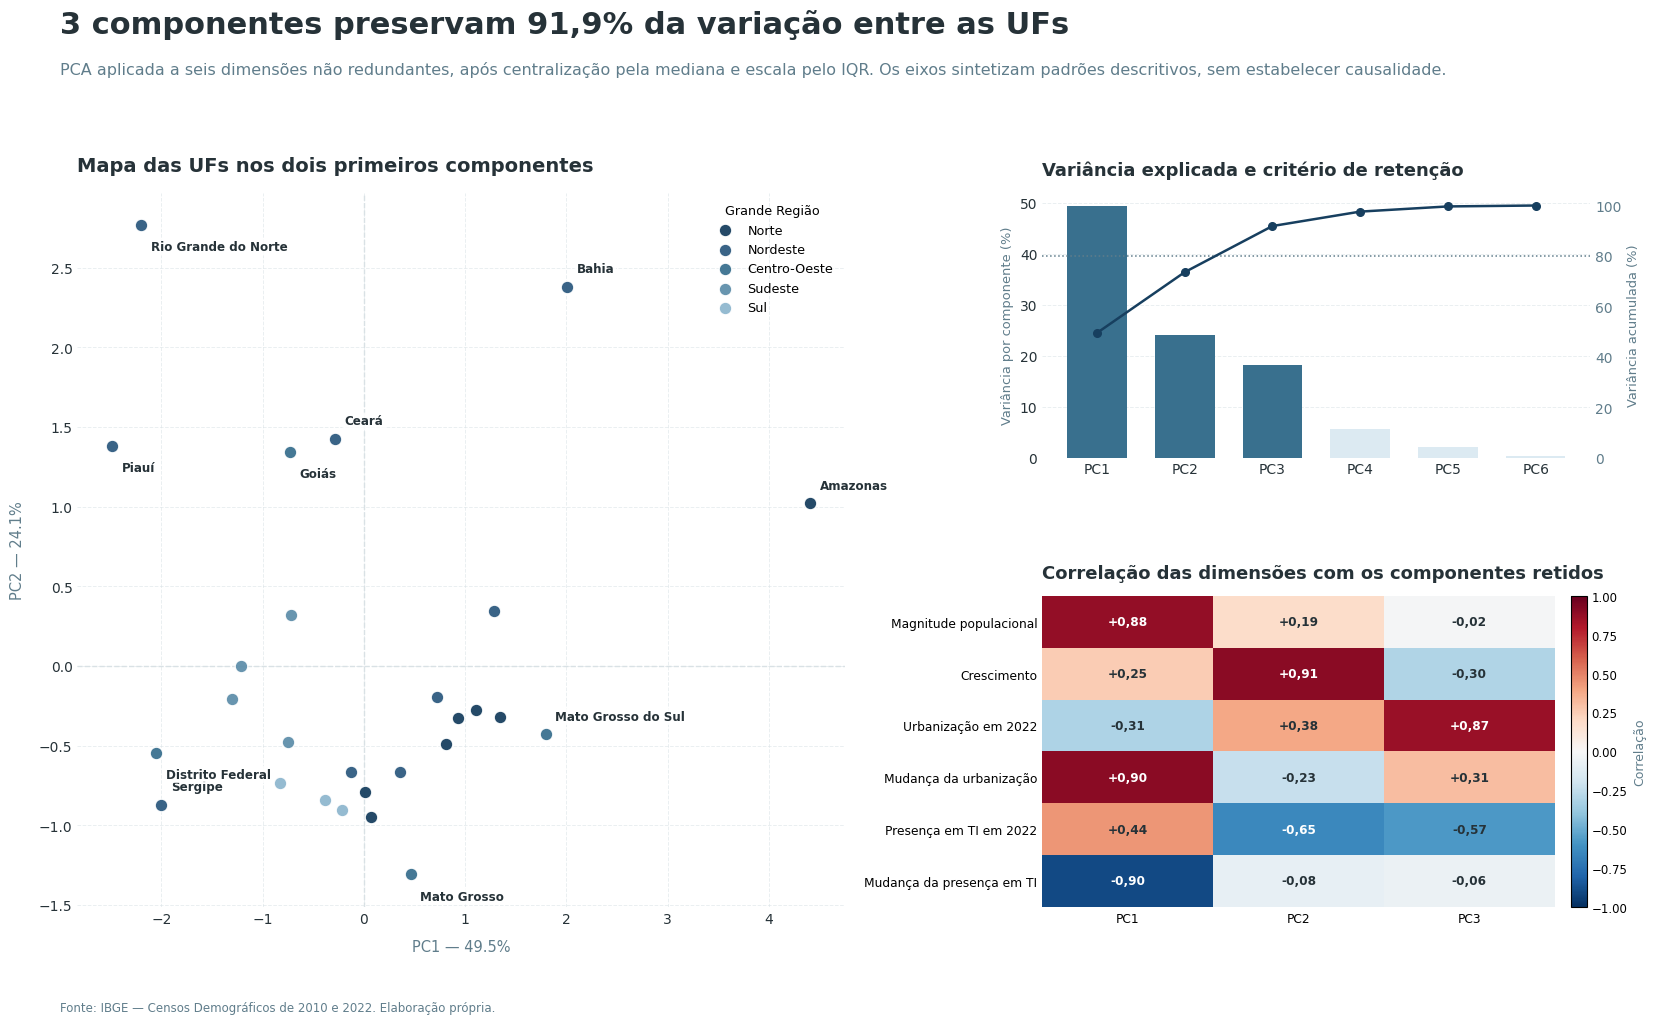

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_pca_perfis_estaduais.png')

In [29]:
caminho_grafico_pca = (
    graficos_estatisticos.plot_pca_perfis_estaduais()
)
caminho_grafico_pca


## 19. Há evidência suficiente para segmentar as UFs?

O K-means é avaliado de **K=2 a K=6** sobre os componentes retidos, sem pressupor previamente que grupos naturais existam. A melhor separação interna não é aceita por si só. Para que uma solução fosse considerada defensável, ela precisaria atender simultaneamente a seis critérios definidos de modo conservador para este estudo:

1. silhouette médio ≥ 0,50;
2. ao menos três UFs no menor agrupamento;
3. ARI mediano ≥ 0,90 em 100 reinicializações;
4. ARI mínimo ≥ 0,50 após a retirada de uma UF por vez;
5. ARI mínimo ≥ 0,50 após a retirada de uma variável por vez;
6. percentil 10 do ARI ≥ 0,50 em 100 subamostras aleatórias de 80% das UFs.

O índice de Rand ajustado (ARI) compara atribuições descontando concordâncias esperadas ao acaso. Os limiares são regras explícitas deste exercício exploratório, não padrões universais.


In [30]:
resultado_agrupamentos = (
    avaliar_agrupamentos_multivariados(df_estatistico)
)
avaliacao_agrupamentos = resultado_agrupamentos["avaliacao"]
estabilidade_agrupamentos = resultado_agrupamentos[
    "estabilidade"
]
atribuicoes_diagnosticas = resultado_agrupamentos[
    "atribuicoes_diagnosticas"
]
k_diagnostico = resultado_agrupamentos["k_diagnostico"]

avaliacao_agrupamentos[
    [
        "K",
        "Silhouette médio",
        "Tamanhos dos agrupamentos",
        "ARI mediano — reinicializações",
        "ARI mínimo — retirada de UF",
        "ARI mínimo — retirada de variável",
        "ARI P10 — subamostras",
        "Critérios atendidos (de 6)",
        "Decisão",
    ]
].round(3)


,K,Silhouette médio,Tamanhos dos agrupamentos,ARI mediano — reinicializações,ARI mínimo — retirada de UF,ARI mínimo — retirada de variável,ARI P10 — subamostras,Critérios atendidos (de 6),Decisão
0,2,0.32,16; 11,0.59,0.57,0.20,-0.00,2,Rejeitada
1,3,0.38,15; 10; 2,0.40,0.36,0.13,0.31,0,Rejeitada
2,4,0.41,15; 7; 3; 2,0.84,0.50,0.24,0.43,1,Rejeitada
3,5,0.34,8; 7; 7; 3; 2,0.61,0.38,0.36,0.44,0,Rejeitada
4,6,0.37,9; 7; 4; 3; 2; 2,0.76,0.65,0.34,0.37,1,Rejeitada


### Resposta

**Nenhuma solução é aceita.** Todos os silhouettes ficam abaixo de 0,50. A solução com melhor qualidade interna, **K=4**, alcança apenas **0,407** e forma grupos de **15, 7, 3 e 2 UFs**. Ela também apresenta ARI mediano de **0,845** nas reinicializações, ARI mínimo de **0,243** quando uma dimensão é retirada e percentil 10 de **0,430** nas subamostras. Dos seis critérios, satisfaz somente a estabilidade mínima à retirada de uma UF.

Os dois grupos menores reproduzem, em grande medida, extremos já identificados: Amazonas e Bahia formam uma dupla, enquanto Ceará, Rio Grande do Norte e Piauí formam um trio. Esse isolamento pode melhorar o silhouette sem demonstrar a existência de perfis amplos e estáveis. A decisão substantiva é, portanto, **não segmentar as UFs** com os indicadores disponíveis.


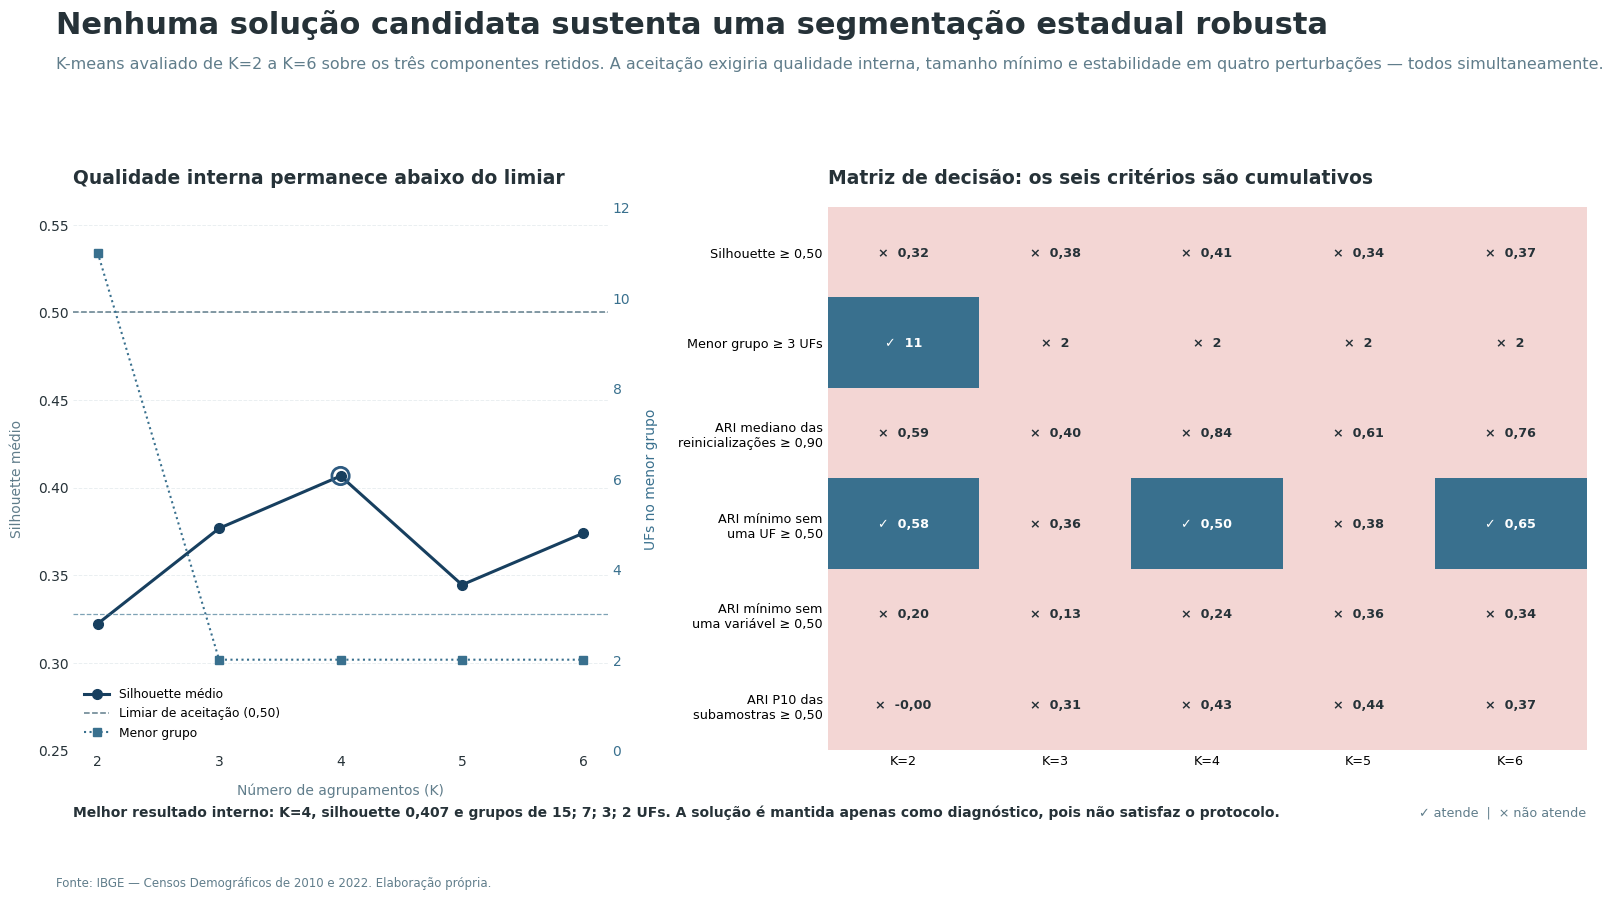

PosixPath('/home/lucas/workspace/pessoal/exploracao-dados-indigenas-2010-2022/outputs/figures/charts/grafico_validacao_agrupamentos_estaduais.png')

In [31]:
caminho_grafico_agrupamentos = (
    graficos_estatisticos.plot_validacao_agrupamentos_estaduais(
        resultado=resultado_agrupamentos
    )
)
caminho_grafico_agrupamentos


## 20. Como interpretar a melhor solução interna?

As atribuições de K=4 são publicadas apenas para tornar o diagnóstico auditável. Os rótulos G1–G4 não constituem tipologia, não recebem nomes substantivos e não devem ser usados como classificação consolidada. A coluna de sinalização anterior permite verificar quando um grupo pequeno coincide com observações atípicas univariadas.


In [32]:
display(
    atribuicoes_diagnosticas.groupby(
        "Agrupamento diagnóstico"
    )["Localidade"].agg(list).to_frame("UFs")
)
display(
    atribuicoes_diagnosticas[
        [
            "Localidade",
            "Região",
            "Agrupamento diagnóstico",
            "Tamanho do agrupamento",
            "Silhouette individual",
            "Sinalizada previamente como atípica",
            "Solução aceita como segmentação",
        ]
    ].round(3)
)


,UFs
Agrupamento diagnóstico,
G1,"[Amazonas, Bahia]"
G2,"[Mato Grosso do Sul, Pará, Pernambuco, Roraima..."
G3,"[São Paulo, Goiás, Minas Gerais, Espírito Sant..."
G4,"[Ceará, Rio Grande do Norte, Piauí]"


,Localidade,Região,Agrupamento diagnóstico,Tamanho do agrupamento,Silhouette individual,Sinalizada previamente como atípica,Solução aceita como segmentação
0,Amazonas,Norte,G1,2,0.38,True,False
1,Bahia,Nordeste,G1,2,0.21,True,False
2,Mato Grosso do Sul,Centro-Oeste,G2,15,0.48,False,False
3,Pará,Norte,G2,15,0.60,False,False
4,Pernambuco,Nordeste,G2,15,0.40,False,False
5,Roraima,Norte,G2,15,0.60,False,False
6,Acre,Norte,G2,15,0.62,False,False
7,Rondônia,Norte,G2,15,0.59,False,False
8,Alagoas,Nordeste,G2,15,0.32,False,False
9,Mato Grosso,Centro-Oeste,G2,15,0.57,False,False


## 21. Exportação das tabelas do Incremento 5


In [33]:
df_multivariado.to_csv(
    CAMINHO_BASE_MULTIVARIADA, index=False
)
variancia_pca.to_csv(CAMINHO_PCA_VARIANCIA, index=False)
cargas_pca.to_csv(CAMINHO_PCA_CARGAS, index=False)
escores_pca.to_csv(CAMINHO_PCA_ESCORES, index=False)
avaliacao_agrupamentos.to_csv(
    CAMINHO_AVALIACAO_AGRUPAMENTOS, index=False
)
estabilidade_agrupamentos.to_csv(
    CAMINHO_ESTABILIDADE_AGRUPAMENTOS, index=False
)
atribuicoes_diagnosticas.to_csv(
    CAMINHO_ATRIBUICOES_DIAGNOSTICAS, index=False
)

pd.Series(
    {
        "Base multivariada padronizada": CAMINHO_BASE_MULTIVARIADA,
        "Variância explicada pela PCA": CAMINHO_PCA_VARIANCIA,
        "Cargas da PCA": CAMINHO_PCA_CARGAS,
        "Escores estaduais da PCA": CAMINHO_PCA_ESCORES,
        "Avaliação dos agrupamentos": CAMINHO_AVALIACAO_AGRUPAMENTOS,
        "Estabilidade dos agrupamentos": CAMINHO_ESTABILIDADE_AGRUPAMENTOS,
        "Atribuições diagnósticas": CAMINHO_ATRIBUICOES_DIAGNOSTICAS,
    },
    name="Arquivo",
).to_frame()


,Arquivo
Base multivariada padronizada,/home/lucas/workspace/pessoal/exploracao-dados...
Variância explicada pela PCA,/home/lucas/workspace/pessoal/exploracao-dados...
Cargas da PCA,/home/lucas/workspace/pessoal/exploracao-dados...
Escores estaduais da PCA,/home/lucas/workspace/pessoal/exploracao-dados...
Avaliação dos agrupamentos,/home/lucas/workspace/pessoal/exploracao-dados...
Estabilidade dos agrupamentos,/home/lucas/workspace/pessoal/exploracao-dados...
Atribuições diagnósticas,/home/lucas/workspace/pessoal/exploracao-dados...


## Síntese final do Estudo 6

1. A população indígena está fortemente concentrada entre as UFs, e a hierarquia de magnitude permaneceu muito estável entre 2010 e 2022.

2. Médias e medidas de concentração são sensíveis sobretudo ao Amazonas; medianas e associações de postos oferecem leituras complementares mais robustas, sem justificar a exclusão de casos extremos.

3. Urbanização e presença em TI apresentam a relação estadual mais intensa e negativa, mas a natureza ecológica dos dados impede interpretação individual ou causal.

4. Três componentes principais preservam 91,86% da variação de seis dimensões não redundantes. Eles distinguem magnitude e mudança da urbanização, crescimento e presença em TI, e nível de urbanização.

5. Nenhuma solução entre dois e seis agrupamentos satisfaz simultaneamente qualidade interna, tamanho mínimo e estabilidade. A ausência de segmentação defensável é um resultado analítico, não uma falha do método.

6. A solução K=4 permanece somente como artefato diagnóstico: seus grupos pequenos coincidem com extremos já conhecidos e se alteram excessivamente quando uma dimensão é omitida.

7. O estudo descreve o universo das 27 UFs com dados agregados. Investigações futuras sobre mecanismos exigiriam outra granularidade, variáveis contextuais adicionais e desenho inferencial apropriado.

Com isso, o Estudo 6 é encerrado sem transformar variação contínua e casos extremos em uma tipologia artificial.
